# Hyperliquid HFT / high-volume trader performance analysis

Analyses trader (non-vault) accounts from the local trade history DuckDB.

- Computes CAGR, Sharpe, Sortino, Calmar, trades/day, max notional exposure
- Caches intermediate results in a separate DuckDB for fast re-runs
- Visualises cumulative PnL for top 5 traders by CAGR

## Prerequisites

Sync trader data into the trade history database:

```shell
SCAN=top_traders INTERACTIVE=false poetry run python scripts/hyperliquid/sync-trade-history.py
```

## Setup

In [ ]:
import pandas as pd
from plotly.offline import init_notebook_mode
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from eth_defi.hyperliquid.session import create_hyperliquid_session
from eth_defi.hyperliquid.trader_stats import TraderStatsDatabase
from eth_defi.monkeypatch import plotly
from eth_defi.research.notebook import (
    display_dataframe_with_html,
    format_large_number,
    set_large_plotly_chart_font,
)

pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = None
pd.options.display.max_rows = None

image_format = "png"
width = 1400
height = 800

init_notebook_mode()
pio.renderers.default = image_format
current_renderer = pio.renderers[image_format]
current_renderer.width = width
current_renderer.height = height
set_large_plotly_chart_font(line_width=3, legend_font_size=14)
pio.templates.default = "custom"

## Connect to databases

In [ ]:
session = create_hyperliquid_session()
db = TraderStatsDatabase()

overview = db.get_source_overview()
display(overview.T.rename(columns={0: "Count"}))

## Build / refresh daily PnL cache

Aggregates fills and funding payments by day per trader using DuckDB SQL.
Only recomputes traders whose source data has changed since last run.

In [3]:
recomputed = db.refresh_daily_pnl()
print(f"Recomputed: {recomputed} traders")

total_cached = db.cache_con.execute("SELECT COUNT(DISTINCT address) FROM daily_pnl").fetchone()[0]
print(f"Total traders in cache: {total_cached}")

Recomputed: 0 traders
Total traders in cache: 219


## Compute per-trader performance metrics

- CAGR, Sharpe, Sortino, Calmar, max drawdown from daily PnL
- Trades/day and max notional exposure from source fills
- Initial capital estimated from ledger deposits

In [ ]:
count = db.compute_metrics(session=session)
print(f"Computed metrics for {count} traders")

## Summary table

All traders sorted by CAGR descending.

In [ ]:
summary_df = db.get_metrics()

HL_BASE_URL = "https://app.hyperliquid.xyz/leaderboard"

def _make_address_link(address: str) -> str:
    short = address[:12] + "..."
    return f'<a href="{HL_BASE_URL}/{address}" target="_blank">{short}</a>'

display_df = pd.DataFrame({
    "Address": summary_df["address"].apply(_make_address_link),
    "Label": summary_df["label"].fillna(""),
    "CAGR": summary_df["cagr"].apply(lambda x: f"{x*100:.1f}%" if pd.notna(x) else "-"),
    "Sharpe": summary_df["sharpe"].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "-"),
    "Sortino": summary_df["sortino"].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "-"),
    "Calmar": summary_df["calmar"].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "-"),
    "Max DD": summary_df["max_drawdown"].apply(lambda x: f"{x*100:.1f}%" if pd.notna(x) else "-"),
    "Net PnL": summary_df["net_pnl"].apply(lambda x: f"${x:,.0f}"),
    "Trades/day": summary_df["trades_per_day"].apply(lambda x: f"{x:,.0f}"),
    "Total trades": summary_df["fill_count"].apply(format_large_number),
    "Max risk ($)": summary_df["max_notional_exposure"].apply(lambda x: f"${x:,.0f}" if pd.notna(x) else "-"),
    "Init capital": summary_df["initial_capital"].apply(lambda x: f"${x:,.0f}" if pd.notna(x) else "-"),
    "Days": summary_df["active_days"],
    "Age (days)": summary_df["account_age_days"].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else "-"),
    "Created": summary_df["account_created_at"].apply(
        lambda x: pd.Timestamp(x, unit="ms").strftime("%Y-%m-%d") if pd.notna(x) else "-"
    ),
})

display_dataframe_with_html(display_df)

## Top 5 trader PnL charts

Cumulative net PnL for the top 5 traders by CAGR.

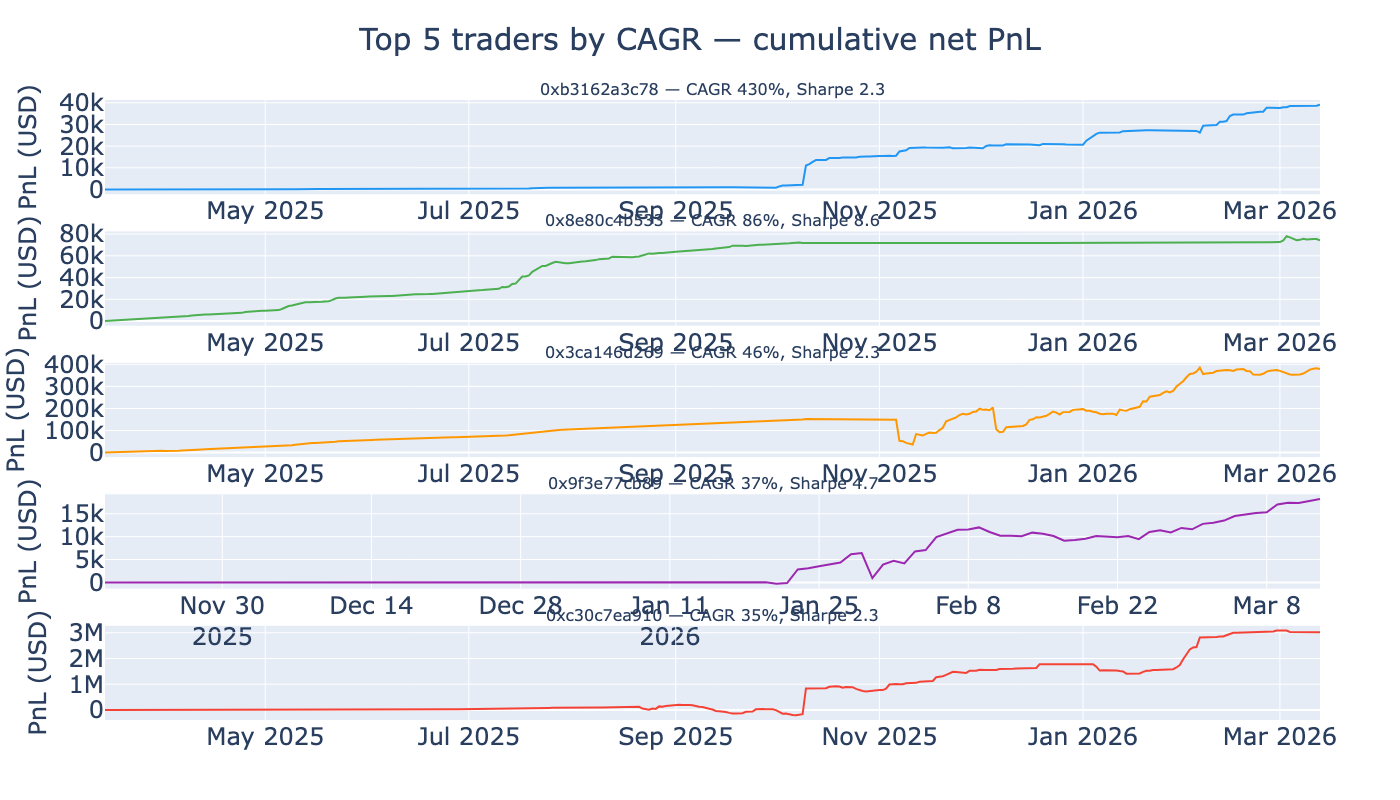

In [6]:
# Pick top 5 with valid CAGR
top5 = summary_df[summary_df["cagr"].notna()].head(5)

if len(top5) == 0:
    print("No traders with valid CAGR found. Skipping PnL charts.")
else:
    # Individual subplots
    colours = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]
    n = len(top5)

    fig = make_subplots(
        rows=n, cols=1,
        shared_xaxes=False,
        subplot_titles=[
            f"{row['label'] or row['address'][:12]} — CAGR {row['cagr']*100:.0f}%, Sharpe {row['sharpe']:.1f}"
            for _, row in top5.iterrows()
        ],
        vertical_spacing=0.06,
    )

    for i, (_, row) in enumerate(top5.iterrows(), 1):
        daily = db.get_daily_pnl(row["address"])
        daily["cumulative_pnl"] = daily["daily_net_pnl"].cumsum()

        label = row["label"] or row["address"][:12]
        fig.add_trace(
            go.Scatter(
                x=daily["trade_date"],
                y=daily["cumulative_pnl"],
                name=label,
                line=dict(color=colours[i - 1], width=2),
                showlegend=False,
            ),
            row=i, col=1,
        )
        fig.update_yaxes(title_text="PnL (USD)", row=i, col=1)

    fig.update_layout(
        title="Top 5 traders by CAGR — cumulative net PnL",
        height=300 * n,
    )
    fig.show()

## PnL overlay — top 5 traders

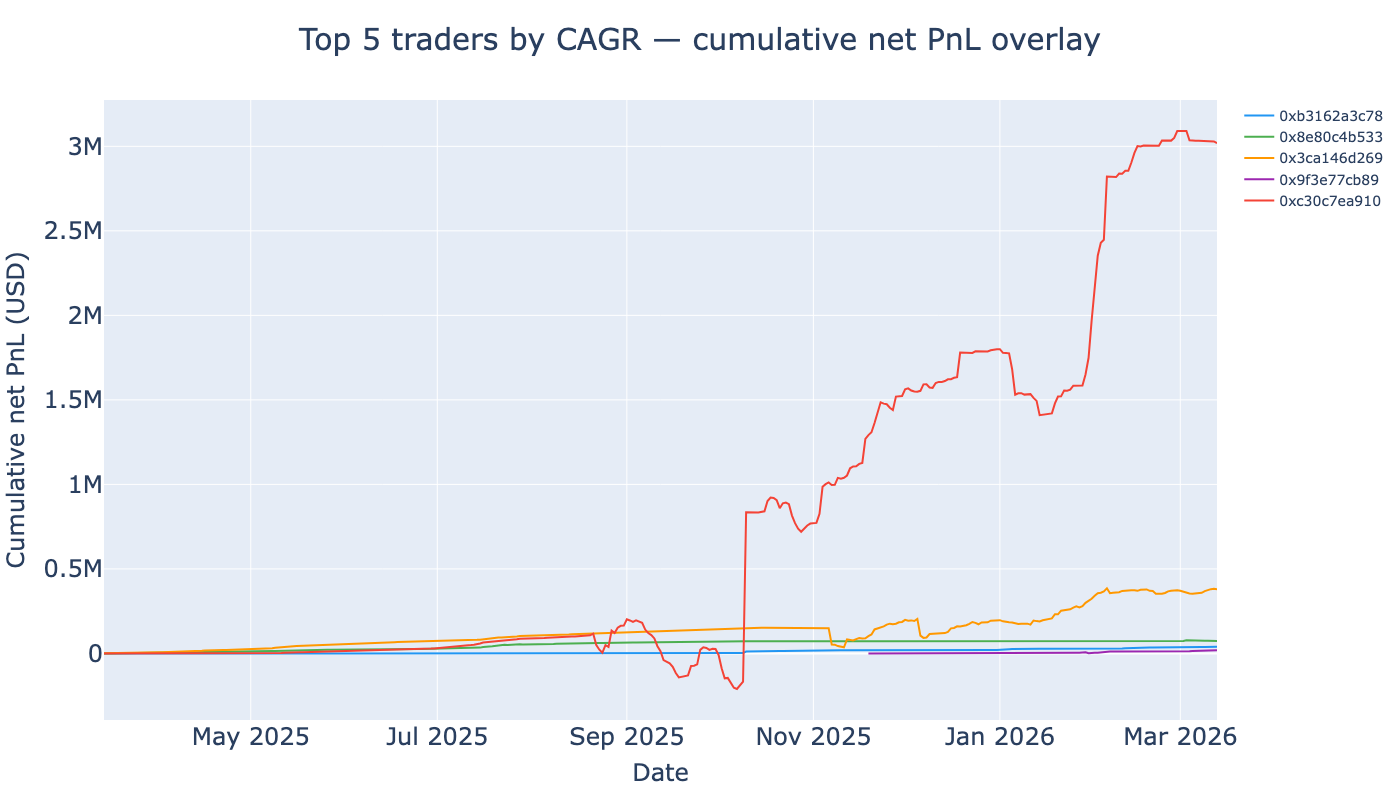

In [7]:
if len(top5) > 0:
    colours = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]
    fig = go.Figure()

    for i, (_, row) in enumerate(top5.iterrows()):
        daily = db.get_daily_pnl(row["address"])
        daily["cumulative_pnl"] = daily["daily_net_pnl"].cumsum()
        label = row["label"] or row["address"][:12]

        fig.add_trace(
            go.Scatter(
                x=daily["trade_date"],
                y=daily["cumulative_pnl"],
                name=label,
                line=dict(color=colours[i], width=2),
            )
        )

    fig.update_layout(
        title="Top 5 traders by CAGR — cumulative net PnL overlay",
        xaxis_title="Date",
        yaxis_title="Cumulative net PnL (USD)",
        height=600,
    )
    fig.show()

## Cleanup

In [8]:
print(f"Cache DB: {db.cache_path}")
db.close()

Cache DB: /Users/moo/.tradingstrategy/vaults/hyperliquid/trader-analysis-cache.duckdb
